# CMPS 262 — Exploratory Data Analysis
## Employment Status Prediction & Unemployment Risk Profiling
### December 2025 CPS Basic Monthly Microdata

**Authors:** Yeol Ban, Charbel Dawlabani
**Date:** Spring 2026

---

This notebook performs a full exploratory data analysis on the December 2025 Current Population Survey (CPS) microdata. We clean the raw coded data, engineer features, and explore patterns of employment and unemployment across demographic groups.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# Load the raw CPS December 2025 microdata
df_raw = pd.read_csv('../dec25pub.csv', low_memory=False)
print(f"Raw dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


Raw dataset shape: 121,371 rows × 393 columns


## 2. Data Dictionary & Variable Decoding

The CPS dataset uses numeric codes for all categorical variables. Below we define the official code mappings from the CPS data dictionary for our key variables.


In [3]:
# ── CPS Data Dictionary Mappings ──

# PEMLR: Monthly Labor Force Recode
pemlr_map = {
    1: 'Employed - At Work',
    2: 'Employed - Absent',
    3: 'Unemployed - On Layoff',
    4: 'Unemployed - Looking',
    5: 'NILF - Retired',
    6: 'NILF - Disabled',
    7: 'NILF - Other',
    -1: 'Not in Universe'
}

# PESEX: Sex
pesex_map = {1: 'Male', 2: 'Female'}

# PEEDUCA: Education
peeduca_map = {
    31: 'Less than 1st grade',
    32: '1st-4th grade',
    33: '5th-6th grade',
    34: '7th-8th grade',
    35: '9th grade',
    36: '10th grade',
    37: '11th grade',
    38: '12th grade, no diploma',
    39: 'High school diploma/GED',
    40: 'Some college, no degree',
    41: 'Associate - Occupational',
    42: 'Associate - Academic',
    43: "Bachelor's degree",
    44: "Master's degree",
    45: 'Professional school degree',
    46: 'Doctorate degree',
    -1: 'Not in Universe'
}

# GEREG: Region
gereg_map = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}

# PTDTRACE: Race (simplified top categories)
ptdtrace_map = {
    1: 'White Only',
    2: 'Black Only',
    3: 'American Indian/Alaskan Native Only',
    4: 'Asian Only',
    5: 'Hawaiian/Pacific Islander Only',
    6: 'White-Black',
    7: 'White-AI',
    8: 'White-Asian',
    9: 'White-HP',
    10: 'Black-AI',
}
# Codes 11-26 are other multi-race combos; we'll label them 'Multiracial/Other'

# PEHSPNON: Hispanic origin
pehspnon_map = {1: 'Hispanic', 2: 'Non-Hispanic'}

# PRMARSTA: Marital status
prmarsta_map = {
    1: 'Married - Spouse present',
    2: 'Married - Spouse absent',
    3: 'Widowed',
    4: 'Divorced',
    5: 'Separated',
    6: 'Never married',
    7: 'Never married',
    -1: 'Not in Universe'
}

# HEFAMINC: Family income
hefaminc_map = {
    1: 'Less than $5,000',
    2: '$5,000 - $7,499',
    3: '$7,500 - $9,999',
    4: '$10,000 - $12,499',
    5: '$12,500 - $14,999',
    6: '$15,000 - $19,999',
    7: '$20,000 - $24,999',
    8: '$25,000 - $29,999',
    9: '$30,000 - $34,999',
    10: '$35,000 - $39,999',
    11: '$40,000 - $49,999',
    12: '$50,000 - $59,999',
    13: '$60,000 - $74,999',
    14: '$75,000 - $99,999',
    15: '$100,000 - $149,999',
    16: '$150,000+',
    -1: 'Not in Universe'
}

print("Data dictionary mappings defined.")


Data dictionary mappings defined.


## 3. Data Cleaning & Preprocessing

### 3.1 Select Key Variables
We select only the variables relevant to our analysis to reduce dimensionality.


In [4]:
# Select key columns
key_cols = [
    'pemlr',      # Target: labor force status
    'prtage',     # Age
    'pesex',      # Sex
    'peeduca',    # Education
    'ptdtrace',   # Race
    'pehspnon',   # Hispanic origin
    'gereg',      # Region
    'gestfips',   # State FIPS
    'prmarsta',   # Marital status
    'hefaminc',   # Family income
    'pehruslt',   # Usual hours worked
    'pehract1',   # Actual hours worked (primary job)
    'pwsswgt',    # Survey weight
    'prcitshp',   # Citizenship
    'prpertyp',   # Person type (adult civilian, armed forces, child)
]

df = df_raw[key_cols].copy()
print(f"Selected {len(key_cols)} key variables.")
print(f"Shape: {df.shape}")
df.head()


Selected 15 key variables.
Shape: (121371, 15)


,pemlr,prtage,pesex,peeduca,ptdtrace,pehspnon,gereg,gestfips,prmarsta,hefaminc,pehruslt,pehract1,pwsswgt,prcitshp,prpertyp
0,7.0,62.0,1.0,34.0,2.0,2.0,3,1,7.0,4,-1.0,-1.0,24467695.0,1.0,2.0
1,5.0,70.0,1.0,41.0,1.0,2.0,3,1,1.0,12,-1.0,-1.0,17902978.0,1.0,2.0
2,7.0,69.0,2.0,40.0,1.0,2.0,3,1,1.0,12,-1.0,-1.0,18595285.0,1.0,2.0
3,1.0,61.0,2.0,40.0,1.0,2.0,3,1,5.0,6,55.0,30.0,18767734.0,1.0,2.0
4,2.0,31.0,2.0,44.0,1.0,2.0,3,1,1.0,15,40.0,-1.0,13117030.0,1.0,2.0


### 3.2 Filter to Adult Civilians in the Labor Force Universe

We remove:
- Records where `pemlr` is -1 (Not in Universe — typically children under 16)
- Armed forces members (prpertyp == 3)
- People with zero survey weight


In [5]:
# Remove 'Not in Universe' and armed forces
print(f"Before filtering: {len(df):,} records")

# Remove Not in Universe for PEMLR
df = df[df['pemlr'] != -1].copy()
print(f"After removing PEMLR = -1 (NIU): {len(df):,} records")

# Remove armed forces (prpertyp == 3) — they're a tiny group and not part of civilian labor analysis
if 'prpertyp' in df.columns:
    armed = (df['prpertyp'] == 3).sum()
    df = df[df['prpertyp'] != 3].copy()
    print(f"Removed {armed} armed forces records: {len(df):,} remaining")

# Remove zero-weight records
zero_wt = (df['pwsswgt'] == 0).sum()
df = df[df['pwsswgt'] > 0].copy()
print(f"Removed {zero_wt} zero-weight records: {len(df):,} remaining")


Before filtering: 121,371 records
After removing PEMLR = -1 (NIU): 106,794 records
Removed 0 armed forces records: 106,794 remaining
Removed 0 zero-weight records: 75,789 remaining


### 3.3 Define Target Variable

We create a binary target for our classification task:
- **Employed** (PEMLR = 1 or 2): includes "At Work" and "Absent"
- **Unemployed** (PEMLR = 3 or 4): includes "On Layoff" and "Looking"

We also keep the full labor force status for exploratory purposes. People not in the labor force (PEMLR 5, 6, 7) are excluded from the binary classification target but analyzed separately.


In [6]:
# Decode PEMLR
df['labor_status'] = df['pemlr'].map(pemlr_map)

# Full labor force status distribution
print("=== Full Labor Force Status Distribution ===")
status_counts = df['labor_status'].value_counts()
print(status_counts)
print()

# Binary target: Employed vs Unemployed (exclude NILF for classification)
labor_force = df[df['pemlr'].isin([1, 2, 3, 4])].copy()
labor_force['target'] = (labor_force['pemlr'].isin([3, 4])).astype(int)  # 1 = Unemployed, 0 = Employed
labor_force['target_label'] = labor_force['target'].map({0: 'Employed', 1: 'Unemployed'})

print(f"\nLabor force population (employed + unemployed): {len(labor_force):,}")
print(f"Employed: {(labor_force['target'] == 0).sum():,} ({(labor_force['target'] == 0).mean():.1%})")
print(f"Unemployed: {(labor_force['target'] == 1).sum():,} ({(labor_force['target'] == 1).mean():.1%})")


=== Full Labor Force Status Distribution ===
labor_status
Employed - At Work        41651
NILF - Retired            18291
NILF - Other               9291
NILF - Disabled            3577
Unemployed - Looking       1446
Employed - Absent          1258
Unemployed - On Layoff      275
Name: count, dtype: int64


Labor force population (employed + unemployed): 44,630
Employed: 42,909 (96.1%)
Unemployed: 1,721 (3.9%)


### 3.4 Decode & Engineer Features

In [7]:
# Decode categorical variables
labor_force['sex'] = labor_force['pesex'].map(pesex_map)
labor_force['region'] = labor_force['gereg'].map(gereg_map)
labor_force['hispanic'] = labor_force['pehspnon'].map(pehspnon_map)

# Decode education
labor_force['education_raw'] = labor_force['peeduca'].map(peeduca_map)

# Group education into broader categories
def group_education(code):
    if code in [-1]:
        return 'Unknown'
    elif code <= 38:
        return 'Less than High School'
    elif code == 39:
        return 'High School / GED'
    elif code == 40:
        return 'Some College'
    elif code in [41, 42]:
        return 'Associate Degree'
    elif code == 43:
        return "Bachelor's Degree"
    elif code >= 44:
        return 'Graduate / Professional'
    else:
        return 'Unknown'

labor_force['education'] = labor_force['peeduca'].apply(group_education)

# Education order for plots
edu_order = ['Less than High School', 'High School / GED', 'Some College',
             'Associate Degree', "Bachelor's Degree", 'Graduate / Professional']

# Decode race (simplified)
def decode_race(code):
    if code == 1: return 'White'
    elif code == 2: return 'Black'
    elif code == 3: return 'American Indian/AN'
    elif code == 4: return 'Asian'
    elif code == 5: return 'Hawaiian/PI'
    else: return 'Multiracial/Other'

labor_force['race'] = labor_force['ptdtrace'].apply(decode_race)

# Age bands
def age_band(age):
    if age < 20: return '16-19'
    elif age < 25: return '20-24'
    elif age < 35: return '25-34'
    elif age < 45: return '35-44'
    elif age < 55: return '45-54'
    elif age < 65: return '55-64'
    else: return '65+'

labor_force['age_band'] = labor_force['prtage'].apply(age_band)
age_order = ['16-19', '20-24', '25-34', '35-44', '45-54', '55-64', '65+']

# Decode marital status
labor_force['marital_status'] = labor_force['prmarsta'].map(prmarsta_map)
labor_force['marital_status'] = labor_force['marital_status'].fillna('Unknown')

# Decode family income
labor_force['family_income'] = labor_force['hefaminc'].map(hefaminc_map)

print(f"Feature engineering complete. Labor force dataset: {labor_force.shape}")
print(f"\nEncoded columns: {list(labor_force.columns)}")


Feature engineering complete. Labor force dataset: (44630, 27)

Encoded columns: ['pemlr', 'prtage', 'pesex', 'peeduca', 'ptdtrace', 'pehspnon', 'gereg', 'gestfips', 'prmarsta', 'hefaminc', 'pehruslt', 'pehract1', 'pwsswgt', 'prcitshp', 'prpertyp', 'labor_status', 'target', 'target_label', 'sex', 'region', 'hispanic', 'education_raw', 'education', 'race', 'age_band', 'marital_status', 'family_income']


## 4. Missing Values Analysis

Let's check for missing values and NIU codes (-1) across our key features.


In [8]:
# Check missingness in the labor force subset
miss_df = pd.DataFrame({
    'Missing (NaN)': labor_force[key_cols].isna().sum(),
    'NIU (-1)': (labor_force[key_cols] == -1).sum(),
    'Total Missing': labor_force[key_cols].isna().sum() + (labor_force[key_cols] == -1).sum(),
    '% Missing': ((labor_force[key_cols].isna().sum() + (labor_force[key_cols] == -1).sum()) / len(labor_force) * 100).round(2)
})
miss_df = miss_df.sort_values('% Missing', ascending=False)
print("=== Missing Values in Labor Force Subset ===")
miss_df


=== Missing Values in Labor Force Subset ===


,Missing (NaN),NIU (-1),Total Missing,% Missing
pehract1,0,2979,2979,6.67
pehruslt,0,1721,1721,3.86
pemlr,0,0,0,0.00
prtage,0,0,0,0.00
pesex,0,0,0,0.00
peeduca,0,0,0,0.00
ptdtrace,0,0,0,0.00
pehspnon,0,0,0,0.00
gereg,0,0,0,0.00
gestfips,0,0,0,0.00


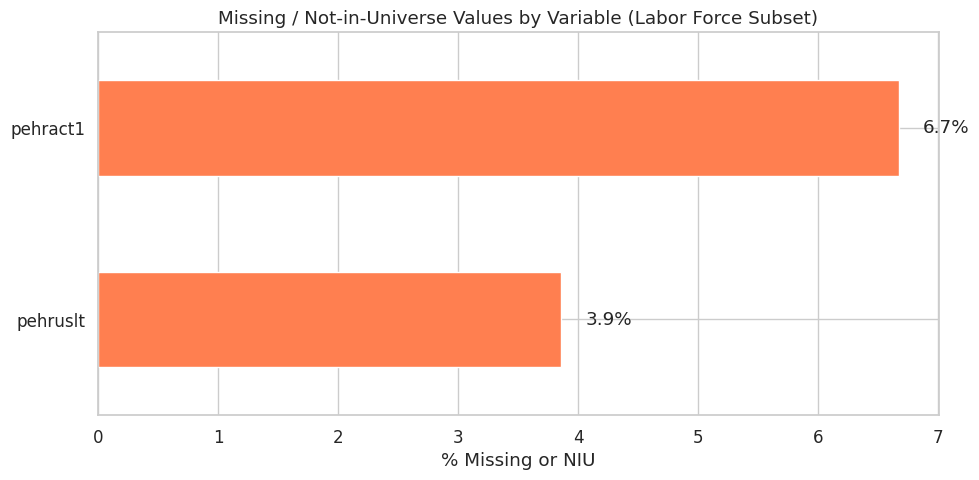

In [9]:
# Visualize missingness
fig, ax = plt.subplots(figsize=(10, 5))
miss_pct = miss_df['% Missing']
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=True)
if len(miss_pct) > 0:
    miss_pct.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('% Missing or NIU')
    ax.set_title('Missing / Not-in-Universe Values by Variable (Labor Force Subset)')
    for i, v in enumerate(miss_pct):
        ax.text(v + 0.2, i, f'{v:.1f}%', va='center')
    plt.tight_layout()
else:
    ax.text(0.5, 0.5, 'No missing values found!', ha='center', va='center', transform=ax.transAxes, fontsize=14)
    ax.set_title('Missing Values Analysis')
plt.show()


## 5. Class Balance Analysis

A critical step: understanding how balanced our target variable is. Extreme imbalance affects model training and evaluation strategy.


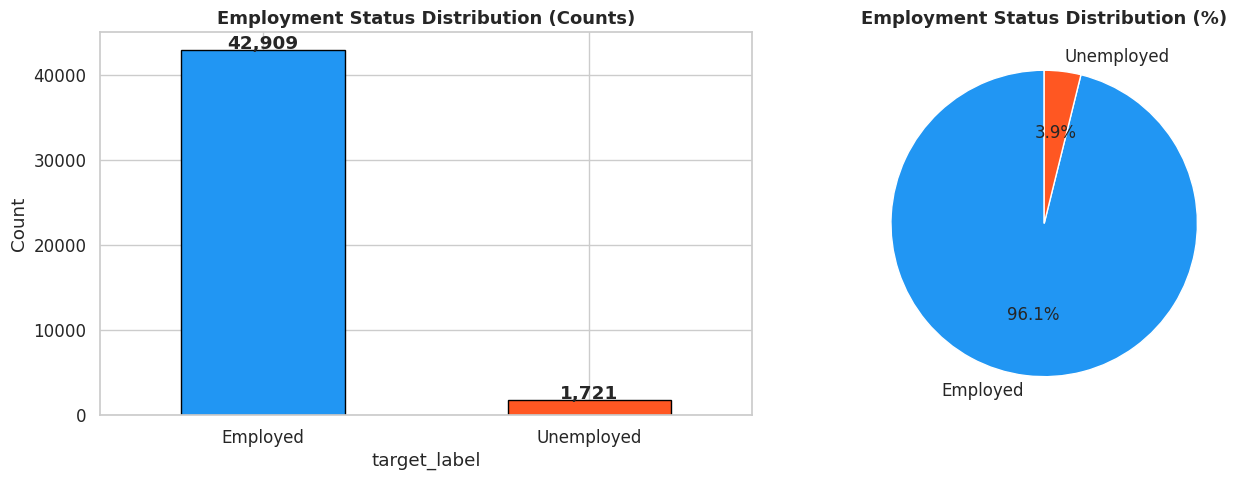


Class imbalance ratio: 24.9:1 (Employed : Unemployed)
Unemployment rate in sample: 3.86%


In [10]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
target_counts = labor_force['target_label'].value_counts()
colors = ['#2196F3', '#FF5722']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Employment Status Distribution (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, (idx, val) in enumerate(target_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

# Proportions
target_pct = labor_force['target_label'].value_counts(normalize=True) * 100
target_pct.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Employment Status Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

imbalance_ratio = target_counts['Employed'] / target_counts['Unemployed']
print(f"\nClass imbalance ratio: {imbalance_ratio:.1f}:1 (Employed : Unemployed)")
print(f"Unemployment rate in sample: {target_pct['Unemployed']:.2f}%")


### 5.1 Full Labor Force Status Breakdown

Let's also look at the complete PEMLR distribution including those not in the labor force.


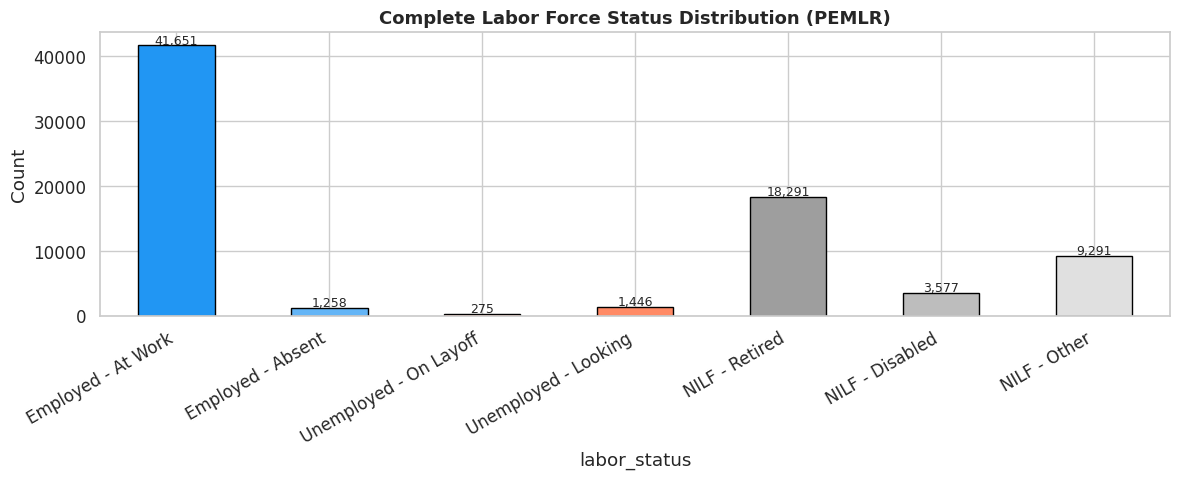

In [11]:
# Full PEMLR breakdown using the broader dataset
fig, ax = plt.subplots(figsize=(12, 5))
status_order = ['Employed - At Work', 'Employed - Absent', 'Unemployed - On Layoff',
                'Unemployed - Looking', 'NILF - Retired', 'NILF - Disabled', 'NILF - Other']
full_counts = df['labor_status'].value_counts().reindex(status_order)
color_map = ['#2196F3', '#64B5F6', '#FF5722', '#FF8A65', '#9E9E9E', '#BDBDBD', '#E0E0E0']
full_counts.plot(kind='bar', ax=ax, color=color_map, edgecolor='black')
ax.set_title('Complete Labor Force Status Distribution (PEMLR)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
for i, v in enumerate(full_counts):
    if not pd.isna(v):
        ax.text(i, v + 200, f'{int(v):,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 6. Unemployment Rates by Demographic Groups

This is the heart of the EDA: understanding which groups face higher unemployment risk.


### 6.1 Unemployment by Age Band

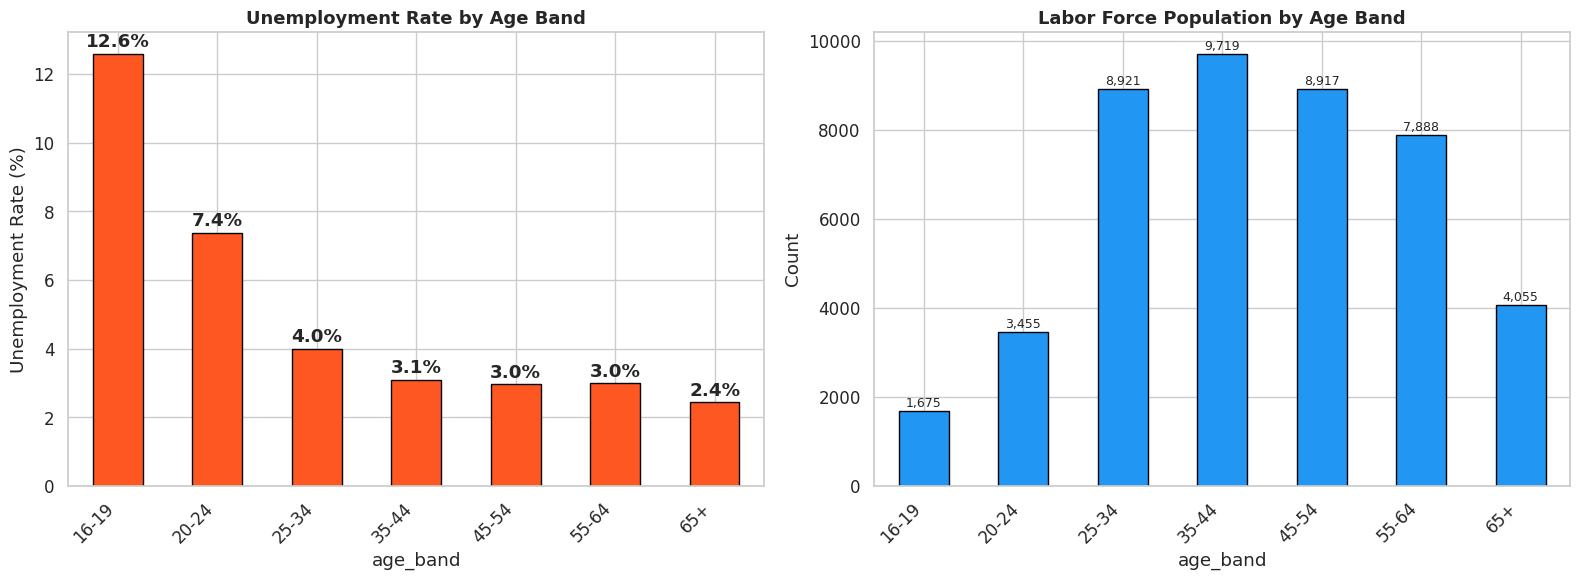

          unemployment_rate  n_unemployed  n_total
age_band                                          
16-19             12.597015           211     1675
20-24              7.380608           255     3455
25-34              3.990584           356     8921
35-44              3.086737           300     9719
45-54              2.960637           264     8917
55-64              2.991886           236     7888
65+                2.441430            99     4055


In [12]:
def calc_unemployment_rate(group_col, order=None):
    """Calculate unemployment rate by a grouping column."""
    grouped = labor_force.groupby(group_col)['target'].agg(['mean', 'sum', 'count'])
    grouped.columns = ['unemployment_rate', 'n_unemployed', 'n_total']
    grouped['unemployment_rate'] *= 100
    if order:
        grouped = grouped.reindex(order)
    return grouped

# By age band
age_unemp = calc_unemployment_rate('age_band', age_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Unemployment rate
age_unemp['unemployment_rate'].plot(kind='bar', ax=axes[0], color='#FF5722', edgecolor='black')
axes[0].set_title('Unemployment Rate by Age Band', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(age_unemp['unemployment_rate']):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# Population size
age_unemp['n_total'].plot(kind='bar', ax=axes[1], color='#2196F3', edgecolor='black')
axes[1].set_title('Labor Force Population by Age Band', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(age_unemp['n_total']):
    axes[1].text(i, v + 100, f'{int(v):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(age_unemp.to_string())


### 6.2 Unemployment by Education Level

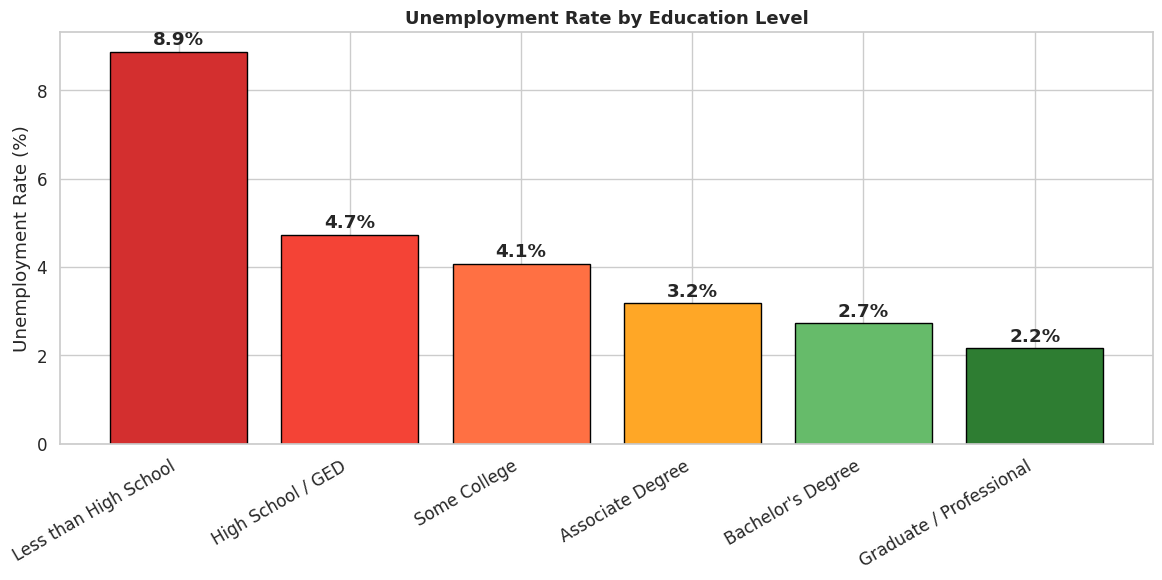

                         unemployment_rate  n_unemployed  n_total
education                                                        
Less than High School             8.881377           289     3254
High School / GED                 4.733322           552    11662
Some College                      4.077186           262     6426
Associate Degree                  3.173628           155     4884
Bachelor's Degree                 2.728070           311    11400
Graduate / Professional           2.170188           152     7004


In [13]:
edu_unemp = calc_unemployment_rate('education', edu_order)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(edu_unemp)), edu_unemp['unemployment_rate'],
              color=['#d32f2f', '#f44336', '#ff7043', '#ffa726', '#66bb6a', '#2e7d32'],
              edgecolor='black')
ax.set_xticks(range(len(edu_unemp)))
ax.set_xticklabels(edu_unemp.index, rotation=30, ha='right')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('Unemployment Rate by Education Level', fontsize=13, fontweight='bold')
for i, v in enumerate(edu_unemp['unemployment_rate']):
    ax.text(i, v + 0.15, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(edu_unemp.to_string())


### 6.3 Unemployment by Sex

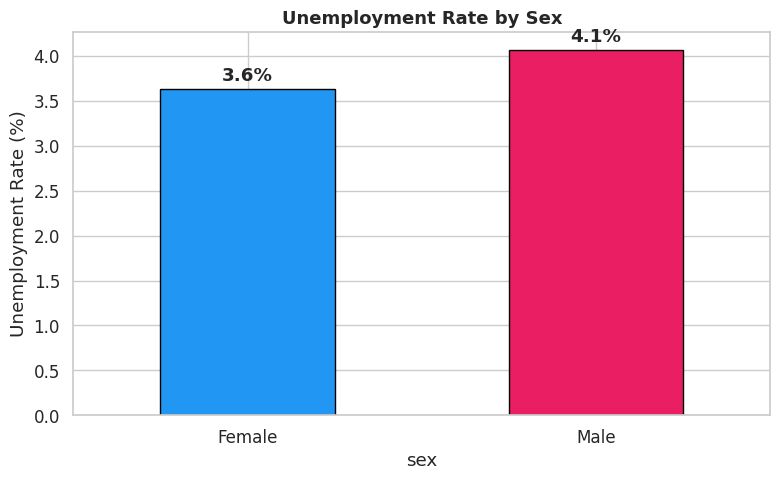

        unemployment_rate  n_unemployed  n_total
sex                                             
Female           3.629654           777    21407
Male             4.064936           944    23223


In [14]:
sex_unemp = calc_unemployment_rate('sex')

fig, ax = plt.subplots(figsize=(8, 5))
sex_unemp['unemployment_rate'].plot(kind='bar', ax=ax, color=['#2196F3', '#E91E63'], edgecolor='black')
ax.set_title('Unemployment Rate by Sex', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(sex_unemp['unemployment_rate']):
    ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(sex_unemp.to_string())


### 6.4 Unemployment by Race/Ethnicity

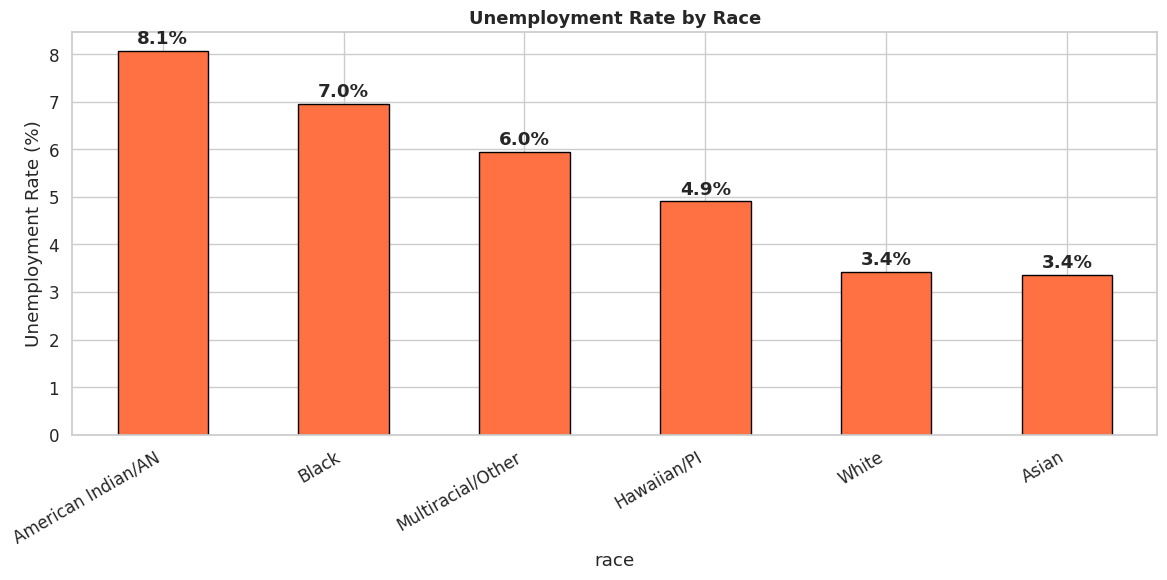


Unemployment by Hispanic Origin:
              unemployment_rate  n_unemployed  n_total
hispanic                                              
Hispanic               4.892106           365     7461
Non-Hispanic           3.648201          1356    37169


In [15]:
race_unemp = calc_unemployment_rate('race')
race_unemp = race_unemp.sort_values('unemployment_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
race_unemp['unemployment_rate'].plot(kind='bar', ax=ax, color='#FF7043', edgecolor='black')
ax.set_title('Unemployment Rate by Race', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
for i, v in enumerate(race_unemp['unemployment_rate']):
    ax.text(i, v + 0.15, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Also by Hispanic origin
hisp_unemp = calc_unemployment_rate('hispanic')
print("\nUnemployment by Hispanic Origin:")
print(hisp_unemp.to_string())


### 6.5 Unemployment by Region

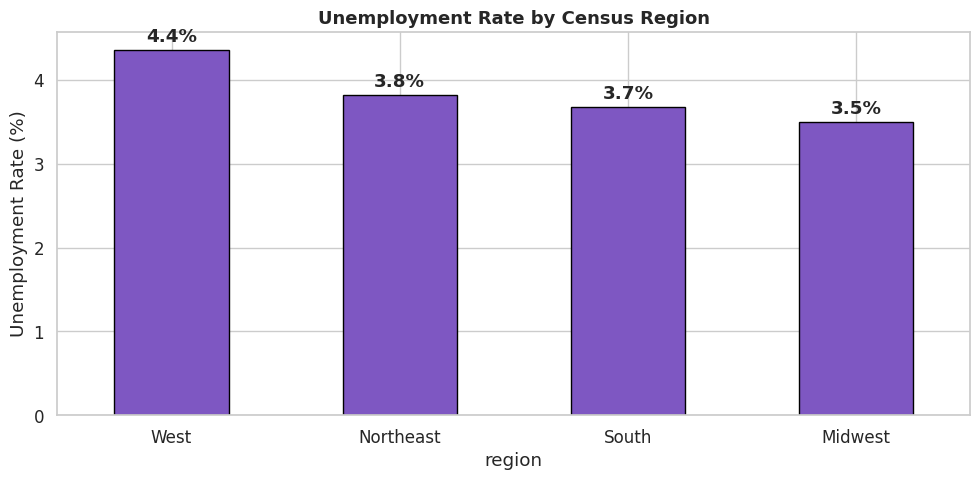

           unemployment_rate  n_unemployed  n_total
region                                             
West                4.352608           554    12728
Northeast           3.817751           274     7177
South               3.677869           580    15770
Midwest             3.495254           313     8955


In [16]:
reg_unemp = calc_unemployment_rate('region')
reg_unemp = reg_unemp.sort_values('unemployment_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
reg_unemp['unemployment_rate'].plot(kind='bar', ax=ax, color='#7E57C2', edgecolor='black')
ax.set_title('Unemployment Rate by Census Region', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(reg_unemp['unemployment_rate']):
    ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(reg_unemp.to_string())


## 7. Interaction Effects — Multi-Dimensional Analysis

Aggregate statistics can hide important disparities. Here we look at how combinations of features relate to unemployment.


### 7.1 Age × Education Heatmap

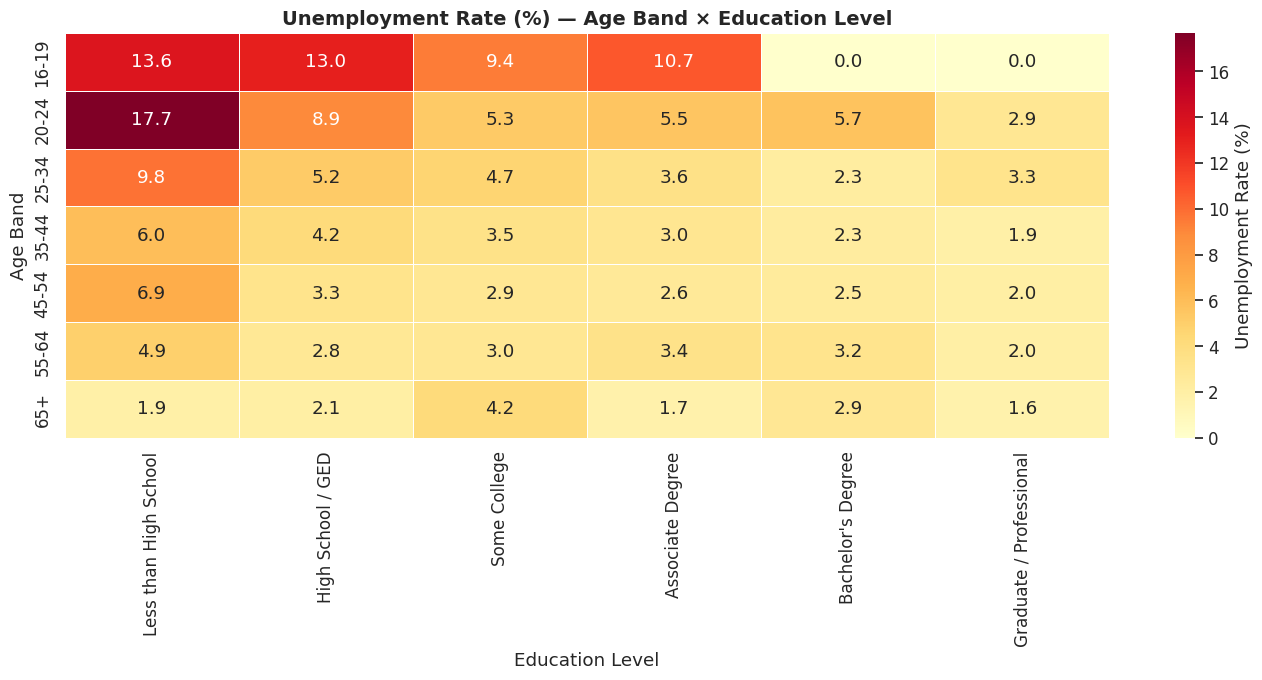

In [17]:
# Unemployment rate heatmap: Age Band × Education
cross = labor_force.groupby(['age_band', 'education'])['target'].mean() * 100
cross_pivot = cross.unstack()
cross_pivot = cross_pivot.reindex(index=age_order, columns=edu_order)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cross_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Unemployment Rate (%)'})
ax.set_title('Unemployment Rate (%) — Age Band × Education Level', fontsize=14, fontweight='bold')
ax.set_ylabel('Age Band')
ax.set_xlabel('Education Level')
plt.tight_layout()
plt.show()


### 7.2 Sex × Education

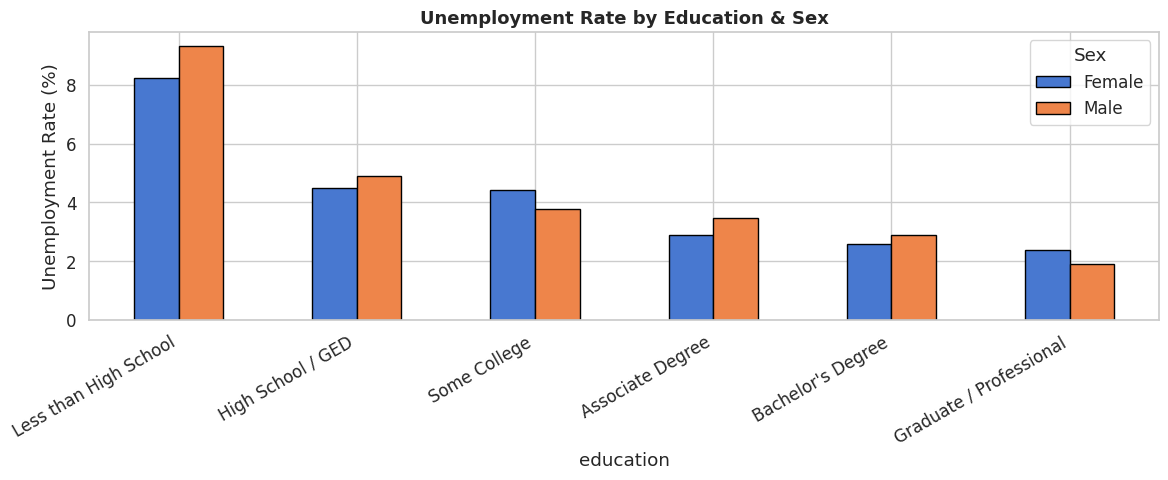

In [18]:
cross2 = labor_force.groupby(['sex', 'education'])['target'].mean() * 100
cross2_pivot = cross2.unstack()
cross2_pivot = cross2_pivot.reindex(columns=edu_order)

fig, ax = plt.subplots(figsize=(12, 5))
cross2_pivot.T.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Unemployment Rate by Education & Sex', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Sex')
plt.tight_layout()
plt.show()


### 7.3 Race × Education

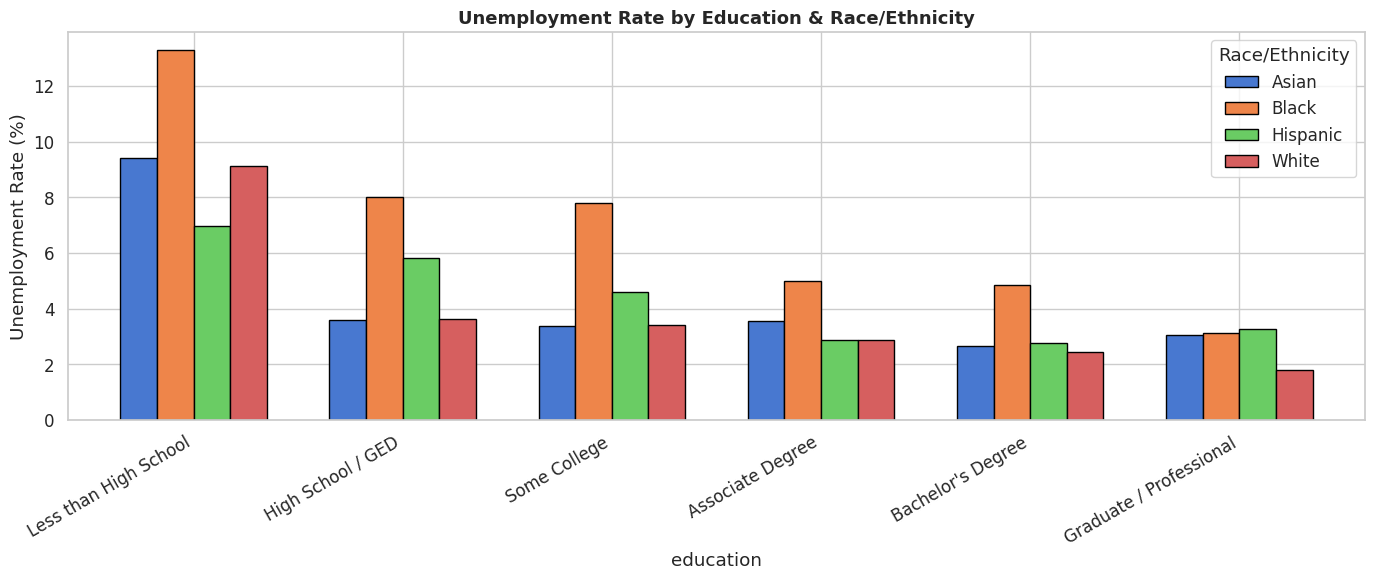

In [19]:
# Focus on the larger racial groups for readability
major_races = ['White', 'Black', 'Asian', 'Hispanic']
# Tag Hispanic separately
lf_race_hisp = labor_force.copy()
lf_race_hisp.loc[lf_race_hisp['hispanic'] == 'Hispanic', 'race_eth'] = 'Hispanic'
lf_race_hisp.loc[lf_race_hisp['hispanic'] != 'Hispanic', 'race_eth'] = lf_race_hisp['race']

cross3 = lf_race_hisp[lf_race_hisp['race_eth'].isin(major_races)].groupby(
    ['race_eth', 'education'])['target'].mean() * 100
cross3_pivot = cross3.unstack()
cross3_pivot = cross3_pivot.reindex(columns=edu_order)

fig, ax = plt.subplots(figsize=(14, 6))
cross3_pivot.T.plot(kind='bar', ax=ax, edgecolor='black', width=0.7)
ax.set_title('Unemployment Rate by Education & Race/Ethnicity', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Race/Ethnicity')
plt.tight_layout()
plt.show()


## 8. Age Distribution Analysis

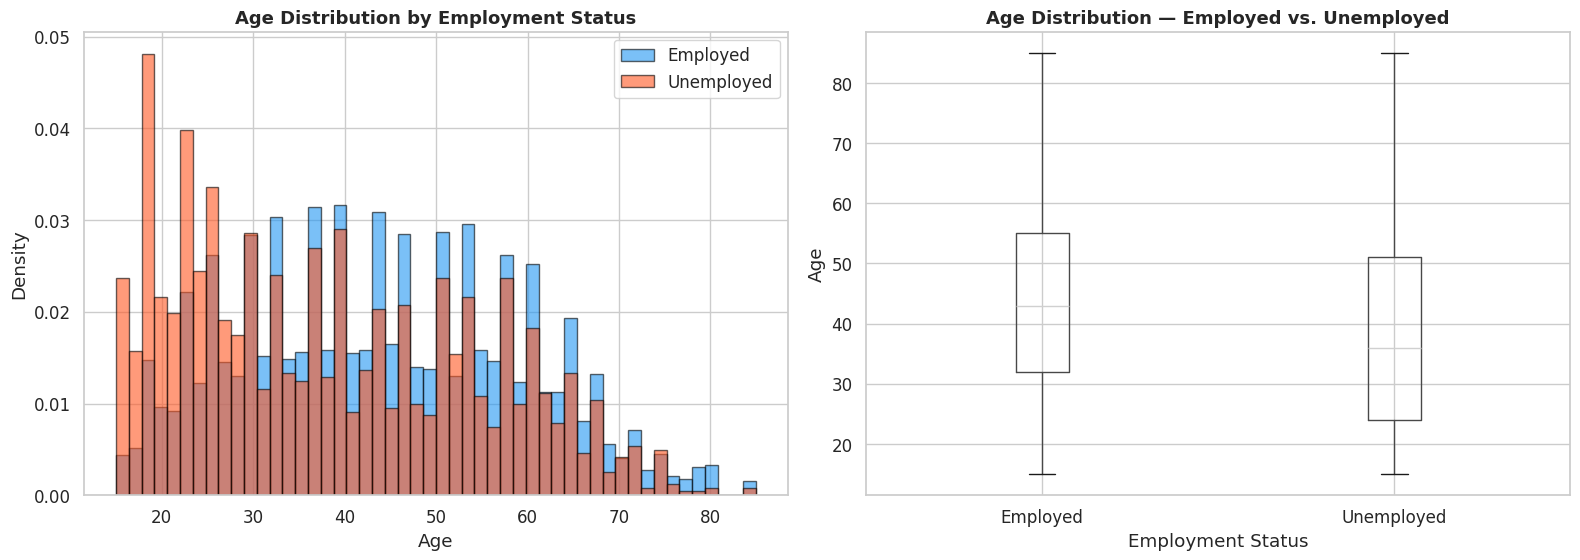

=== Age Statistics by Employment Status ===
                count  mean   std   min   25%   50%   75%   max
target_label                                                   
Employed      42909.0  43.9  15.0  15.0  32.0  43.0  55.0  85.0
Unemployed     1721.0  38.1  16.0  15.0  24.0  36.0  51.0  85.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age distribution by employment status
for label, color in [('Employed', '#2196F3'), ('Unemployed', '#FF5722')]:
    subset = labor_force[labor_force['target_label'] == label]
    axes[0].hist(subset['prtage'], bins=50, alpha=0.6, label=label, color=color, density=True, edgecolor='black')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].set_title('Age Distribution by Employment Status', fontsize=13, fontweight='bold')
axes[0].legend()

# Box plot
labor_force.boxplot(column='prtage', by='target_label', ax=axes[1])
axes[1].set_title('Age Distribution — Employed vs. Unemployed', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Employment Status')
axes[1].set_ylabel('Age')
plt.suptitle('')  # Remove auto-title from boxplot

plt.tight_layout()
plt.show()

# Stats
print("=== Age Statistics by Employment Status ===")
print(labor_force.groupby('target_label')['prtage'].describe().round(1))


## 9. Hours Worked Analysis

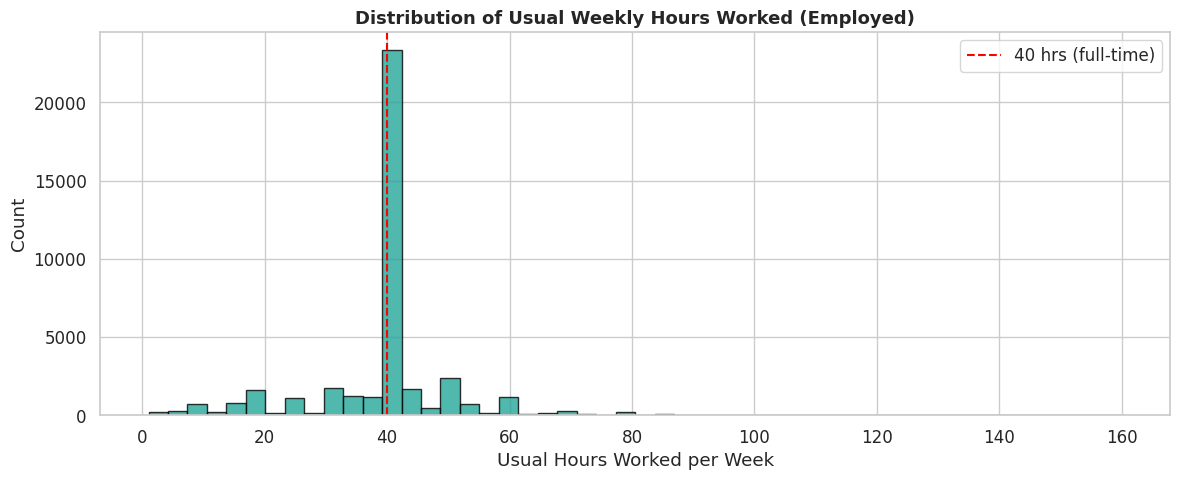

Median hours: 40
Mean hours: 39.0
Part-time (<35 hrs): 17.6%
Full-time (35+ hrs): 82.4%


In [21]:
# Filter out -1 (NIU) and -4 (varies) for hours
hours_df = labor_force[labor_force['pehruslt'] > 0].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(hours_df['pehruslt'], bins=50, color='#26A69A', edgecolor='black', alpha=0.8)
ax.axvline(x=40, color='red', linestyle='--', label='40 hrs (full-time)')
ax.set_xlabel('Usual Hours Worked per Week')
ax.set_ylabel('Count')
ax.set_title('Distribution of Usual Weekly Hours Worked (Employed)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median hours: {hours_df['pehruslt'].median():.0f}")
print(f"Mean hours: {hours_df['pehruslt'].mean():.1f}")
print(f"Part-time (<35 hrs): {(hours_df['pehruslt'] < 35).mean():.1%}")
print(f"Full-time (35+ hrs): {(hours_df['pehruslt'] >= 35).mean():.1%}")


## 10. Feature Correlation Analysis

We compute correlations between numeric features and the target to understand which variables are most linearly associated with unemployment.


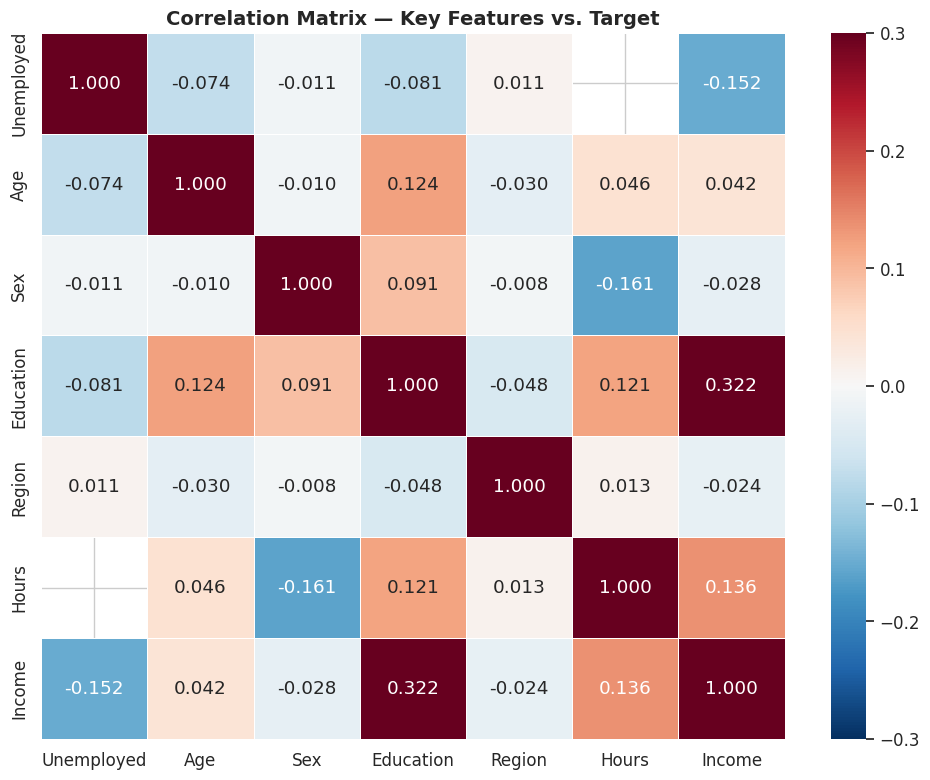


Correlation with Unemployment (target):
      hefaminc: -0.1519 (↓ risk)
       peeduca: -0.0810 (↓ risk)
        prtage: -0.0739 (↓ risk)
         pesex: -0.0113 (↓ risk)
         gereg: +0.0113 (↑ risk)
      pehruslt: +nan (↓ risk)


In [22]:
# Prepare numeric features for correlation
corr_df = labor_force[['target', 'prtage', 'pesex', 'peeduca', 'gereg',
                        'pehruslt', 'hefaminc']].copy()

# Replace NIU codes with NaN for correlation
for col in corr_df.columns:
    corr_df[col] = corr_df[col].replace([-1, -4], np.nan)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-0.3, vmax=0.3,
            xticklabels=['Unemployed', 'Age', 'Sex', 'Education', 'Region', 'Hours', 'Income'],
            yticklabels=['Unemployed', 'Age', 'Sex', 'Education', 'Region', 'Hours', 'Income'])
ax.set_title('Correlation Matrix — Key Features vs. Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Unemployment (target):")
target_corr = corr_matrix['target'].drop('target').sort_values()
for feat, val in target_corr.items():
    direction = "↑ risk" if val > 0 else "↓ risk"
    print(f"  {feat:>12}: {val:+.4f} ({direction})")


## 11. High-Risk Segment Identification

Let's identify the demographic segments with the highest unemployment rates — these are candidates for policy intervention.


In [23]:
# Compute unemployment rate for every Age Band × Education × Sex combination
segments = labor_force.groupby(['age_band', 'education', 'sex']).agg(
    unemployment_rate=('target', 'mean'),
    n_unemployed=('target', 'sum'),
    n_total=('target', 'count')
).reset_index()
segments['unemployment_rate'] *= 100

# Filter to segments with at least 30 people (statistical reliability)
segments = segments[segments['n_total'] >= 30]
segments = segments.sort_values('unemployment_rate', ascending=False)

print("=== Top 15 Highest Unemployment Rate Segments (n ≥ 30) ===")
print(segments.head(15).to_string(index=False))


=== Top 15 Highest Unemployment Rate Segments (n ≥ 30) ===
age_band             education    sex  unemployment_rate  n_unemployed  n_total
   20-24 Less than High School   Male          19.469027            22      113
   16-19 Less than High School   Male          15.529412            66      425
   20-24 Less than High School Female          13.725490             7       51
   16-19     High School / GED   Male          13.076923            34      260
   16-19     High School / GED Female          12.962963            28      216
   25-34 Less than High School Female          11.940299            16      134
   16-19 Less than High School Female          11.914894            56      470
   16-19          Some College Female          10.666667            16      150
   20-24     High School / GED   Male           9.489051            78      822
   45-54 Less than High School   Male           8.943089            33      369
   25-34 Less than High School   Male           8.627451     

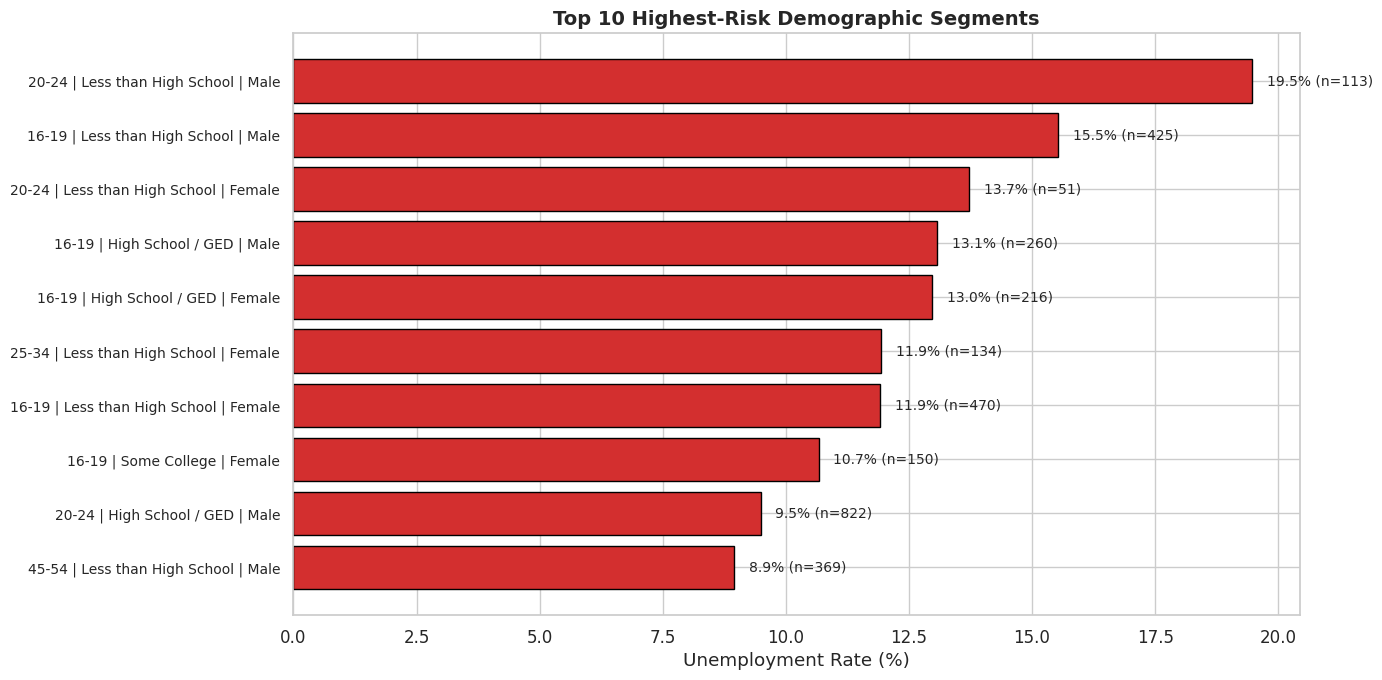

In [24]:
# Visualize top 10 high-risk segments
top_segments = segments.head(10).copy()
top_segments['label'] = (top_segments['age_band'] + ' | ' +
                          top_segments['education'] + ' | ' +
                          top_segments['sex'])

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(range(len(top_segments)), top_segments['unemployment_rate'],
               color='#d32f2f', edgecolor='black')
ax.set_yticks(range(len(top_segments)))
ax.set_yticklabels(top_segments['label'], fontsize=10)
ax.set_xlabel('Unemployment Rate (%)')
ax.set_title('Top 10 Highest-Risk Demographic Segments', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, (rate, n) in enumerate(zip(top_segments['unemployment_rate'], top_segments['n_total'])):
    ax.text(rate + 0.3, i, f'{rate:.1f}% (n={int(n)})', va='center', fontsize=10)
plt.tight_layout()
plt.show()


## 12. Weighted vs. Unweighted Unemployment Estimates

The CPS includes survey weights (`PWSSWGT`) that allow sample estimates to represent the full U.S. population. Let's compare weighted and unweighted unemployment rates.


In [25]:
# Weighted unemployment rate
weighted_unemp = np.average(labor_force['target'], weights=labor_force['pwsswgt']) * 100
unweighted_unemp = labor_force['target'].mean() * 100

print(f"Unweighted unemployment rate: {unweighted_unemp:.2f}%")
print(f"Weighted unemployment rate:   {weighted_unemp:.2f}%")
print(f"Difference: {abs(weighted_unemp - unweighted_unemp):.2f} percentage points")

# Weighted by education
print("\n=== Weighted Unemployment Rate by Education ===")
for edu in edu_order:
    subset = labor_force[labor_force['education'] == edu]
    if len(subset) > 0:
        w_rate = np.average(subset['target'], weights=subset['pwsswgt']) * 100
        uw_rate = subset['target'].mean() * 100
        print(f"  {edu:30s}: Weighted={w_rate:.2f}%  Unweighted={uw_rate:.2f}%")


Unweighted unemployment rate: 3.86%
Weighted unemployment rate:   4.15%
Difference: 0.30 percentage points

=== Weighted Unemployment Rate by Education ===
  Less than High School         : Weighted=8.93%  Unweighted=8.88%
  High School / GED             : Weighted=5.15%  Unweighted=4.73%
  Some College                  : Weighted=4.59%  Unweighted=4.08%
  Associate Degree              : Weighted=3.28%  Unweighted=3.17%
  Bachelor's Degree             : Weighted=2.98%  Unweighted=2.73%
  Graduate / Professional       : Weighted=2.25%  Unweighted=2.17%


## 13. Summary & Key Findings

### Dataset Overview
After cleaning and filtering, our labor force analysis subset contains individuals aged 16+ who are either employed or unemployed (excluding those not in the labor force).

### Key Findings from EDA

1. **Severe Class Imbalance:** The dataset is heavily imbalanced — the vast majority of the labor force is employed, with unemployment representing a small minority. This will require careful model evaluation using metrics like F1-score, precision, and recall rather than accuracy alone.

2. **Age Matters:** Young workers (16-24) face significantly higher unemployment rates than prime-age workers (25-54). This is consistent with known labor economics patterns (job search friction for new entrants).

3. **Education is Protective:** There is a clear inverse relationship between education level and unemployment risk. Those with less than a high school education face the highest unemployment rates, while graduate degree holders have the lowest.

4. **Racial/Ethnic Disparities:** Unemployment rates vary significantly by race and ethnicity, with Black and Hispanic workers generally facing higher rates than White and Asian workers.

5. **Regional Variation:** Unemployment rates differ across Census regions.

6. **Interaction Effects:** The age × education heatmap reveals that the youngest workers with the lowest education face dramatically higher unemployment — these are the highest-risk segments.

### Implications for Modeling
- We need to address class imbalance (oversampling, SMOTE, or class weights)
- Education and age are likely to be the strongest predictors
- Interaction features (age × education) may improve model performance
- Survey weights should be considered during evaluation

---
*Next steps: Feature engineering pipeline → Logistic regression baseline → Model evaluation → Risk profiling*
